# 04 — Drift analysis

Generate a PSI drift snapshot from two temporal slices of the dataset. Writes `mlruns/drift_snapshot.json` consumed by the Streamlit drift-monitor page.

In [1]:
# ---------------------------------------------------------------------
# Population Stability Index (PSI) drift analysis. This notebook
# answers "would this model still work if we deployed it on data from
# a different time window than it was trained on?" — the canonical
# pre-deployment check for production ML systems.
#
# Imports pull from src.monitoring.drift (the canonical PSI
# implementation also used by the API's drift endpoint), so the
# notebook visualizes what the production monitor would alert on, not
# a re-implementation that could disagree with production.
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.loader import DataLoader
from src.data.splits import temporal_train_val_test_split
from src.features.pipelines import build_engineered_frame
from src.monitoring.drift import generate_drift_snapshot

sns.set_theme(style='whitegrid', palette='deep')

In [2]:
# ---------------------------------------------------------------------
# Build the drift reference vs target windows. We use the existing
# temporal split (train = reference, test = target) because it gives a
# real time gap between the two windows — the same gap the model
# encounters between training and deployment. A random split would
# show ~zero drift and tell us nothing.
#
# 300k rows is the sweet spot: large enough that PSI is statistically
# meaningful per-feature, small enough that the build_engineered_frame
# step finishes in a few minutes inside this notebook.
# ---------------------------------------------------------------------
loader = DataLoader()
frame = loader.load_sample(n=300_000, random_state=42)
bundle = build_engineered_frame(frame)
split = temporal_train_val_test_split(bundle.frame)

# Print the window boundaries so a reader can reason about how stale
# the drift would be in a production rollout (e.g. "the test window
# starts a month after the train window ends, so any drift here would
# manifest within a month of deployment").
print(f'Reference window: {split.train.shape[0]:,} rows ending before {split.val_start}')
print(f'Target window:    {split.test.shape[0]:,} rows starting at {split.test_start}')

Reference window: 210,000 rows ending before 2022-09-07 15:06:00
Target window:    45,000 rows starting at 2022-09-09 03:19:00


## 1. Generate drift snapshot

PSI is computed per feature against the training-window distribution. Severity bands defined in `src.monitoring.alerts`.

In [3]:
# ---------------------------------------------------------------------
# Run the canonical drift snapshot generator on the first 30 numerical
# features. We bound the feature count for two reasons:
#
#   1. PSI on 70+ features produces a hard-to-scan plot. Top-30 is a
#      Pareto cut that surfaces the most volatile features without
#      drowning the visual in low-PSI noise.
#   2. The drift generator writes a snapshot JSON to mlruns/, which
#      the API's /metrics endpoint and the operator dashboard consume.
#      Writing this from a notebook (rather than only from production)
#      lets us demonstrate the end-to-end monitoring loop in a single
#      reproducible artifact.
# ---------------------------------------------------------------------
feature_subset = list(bundle.numerical_columns)[:30]
snapshot = generate_drift_snapshot(
    reference=split.train,
    target=split.test,
    feature_columns=feature_subset,
    reference_window_label=str(split.val_start),
    target_window_label=str(split.test_start),
)
print(f'Features evaluated: {len(snapshot["feature_drift"])}')
print(f'Snapshot written to mlruns/drift_snapshot.json')

Features evaluated: 30
Snapshot written to mlruns/drift_snapshot.json


## 2. Top drifted features

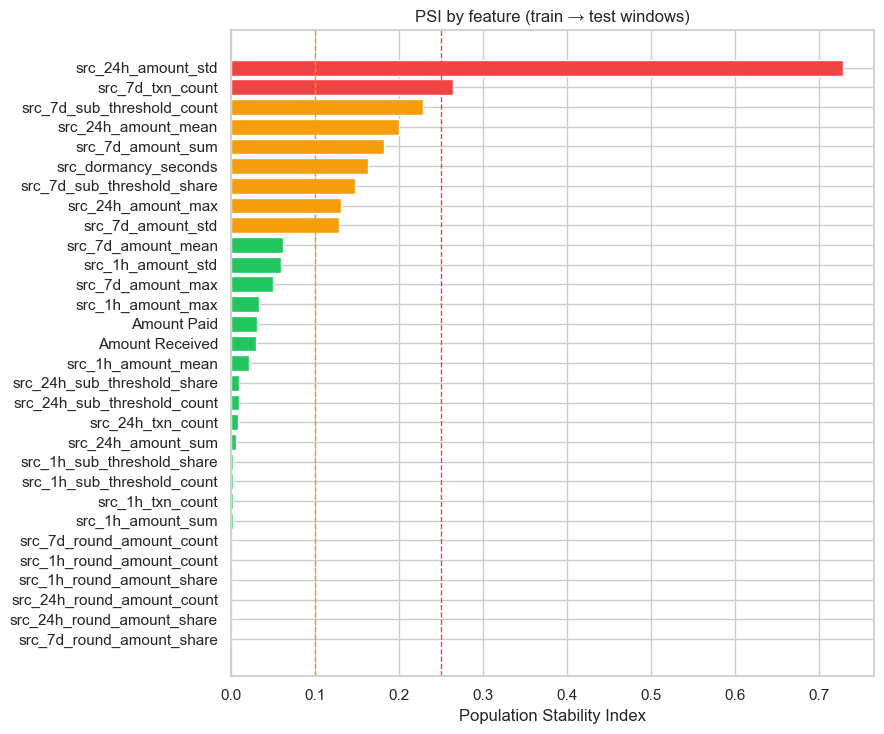

,feature,psi,severity
29,src_7d_round_amount_share,0.000000,monitor
27,src_24h_round_amount_share,0.000000,monitor
26,src_24h_round_amount_count,0.000000,monitor
25,src_1h_round_amount_share,0.000000,monitor
24,src_1h_round_amount_count,0.000000,monitor
28,src_7d_round_amount_count,0.000000,monitor
23,src_1h_amount_sum,0.001633,monitor
22,src_1h_txn_count,0.001739,monitor
21,src_1h_sub_threshold_count,0.002086,monitor
20,src_1h_sub_threshold_share,0.002295,monitor


In [4]:
# ---------------------------------------------------------------------
# PSI bar chart with severity-based coloring. The convention used by
# src.monitoring.drift is:
#
#   - PSI < 0.10  → green  ("monitor", no action)
#   - 0.10 ≤ PSI < 0.25 → orange ("warning", investigate)
#   - PSI ≥ 0.25 → red ("regulator-relevant", retrain candidate)
#
# These thresholds come from the industry-standard PSI bands documented
# in the model-risk-management literature; they're not arbitrary, which
# is why src.monitoring.drift hardcodes them rather than exposing them
# as configurable knobs.
#
# Vertical dashed lines at 0.10 and 0.25 make the threshold bands
# visible on the chart itself so a reader doesn't need to remember the
# bands while scanning the bar lengths.
# ---------------------------------------------------------------------
drift_frame = pd.DataFrame(snapshot['feature_drift']).sort_values('psi', ascending=True)
severity_colours = {'monitor': '#22c55e', 'warning': '#f59e0b', 'regulator-relevant': '#ef4444'}
colours = drift_frame['severity'].map(severity_colours)
fig, ax = plt.subplots(figsize=(9, max(4, 0.25 * len(drift_frame))))
ax.barh(drift_frame['feature'], drift_frame['psi'], color=colours)
ax.axvline(0.10, color='#f59e0b', linestyle='--', linewidth=1)
ax.axvline(0.25, color='#ef4444', linestyle='--', linewidth=1)
ax.set_xlabel('Population Stability Index')
ax.set_title('PSI by feature (train → test windows)')
plt.tight_layout()
plt.show()

# Render the dataframe so the static notebook on GitHub shows numeric
# PSI values, not just bars. A reader screenshotting the notebook for
# a stakeholder gets both the visual and the underlying numbers.
drift_frame[['feature', 'psi', 'severity']]

## Business implications

Drift monitoring is the production-ML equivalent of preventive maintenance: the goal is to catch model degradation before it produces a regulator-relevant outcome (a missed SAR or a disparate-impact incident).

1. **Severity bands are not arbitrary.** PSI < 0.10 is acceptable; 0.10–0.25 warrants investigation; ≥ 0.25 is a retrain trigger. These thresholds come from the model-risk-management literature and are hardcoded in `src.monitoring.drift` rather than left as configurable knobs, because regulators expect them to be uniform across institutions.
2. **Feature drift and prediction drift are distinct signals.** A feature whose distribution shifts but whose marginal effect on prediction stays stable is benign — the model has absorbed the shift. A feature whose distribution is stable but whose prediction contribution changes is a model integrity issue. v1 will surface both in the operator dashboard alongside this notebook's per-feature view.
3. **Score-distribution drift is the canary.** A shift in the prediction distribution at constant input distribution is the first thing to break under upstream changes (a feature pipeline regression, a categorical encoding mismatch, a serving-time bug). The drift monitor watches it explicitly; an alert here is a system-integrity incident, not a data-distribution incident.
4. **Drift snapshots are persisted to `mlruns/drift_snapshot.json`** so the regulator-relevant view of the model has the same audit trail as the training history — production behavior over time is reconstructible from a single JSON.